# 01 — Data & EDA

**Goal of the project:** rank Premier League players by on-pitch impact, built up in
three stages: naive on/off plus-minus → RAPM (ridge-adjusted) → xG-RAPM.

**Data:** [Understat](https://understat.com) — match rosters (with substitution
linkage), shot-level xG with minutes — for seasons 2023/24–2025/26, cross-checked
against independent final scores from football-data.co.uk. See `README.md` for
the full acquisition story (FBref was the original plan; it hard-blocks scraping).

This notebook sanity-checks the *stint* table — the core data structure: maximal
intervals of a match during which the 22 (or fewer, after red cards) players on
the pitch are unchanged.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from plimpact.config import load_config
from plimpact.validate import load_tables

cfg = load_config()
tables = load_tables(cfg)
matches, appearances, shots, stints = (
    tables["matches"], tables["appearances"], tables["shots"], tables["stints"]
)
pd.set_option("display.width", 120)

In [2]:
summary = matches.groupby("season").agg(
    matches=("match_id", "count"),
    goals=("home_goals", lambda s: int(s.sum() + matches.loc[s.index, "away_goals"].sum())),
)
summary["goals_per_match"] = (summary["goals"] / summary["matches"]).round(2)
summary

,matches,goals,goals_per_match
season,,,
2023,380,1246,3.28
2024,380,1115,2.93
2025,380,1045,2.75


       n_stints  total_min
count   1140.00    1140.00
mean       6.48      90.72
std        1.23       0.45
min        3.00      90.00
25%        6.00      90.00
50%        6.00      91.00
75%        7.00      91.00
max       11.00      92.00


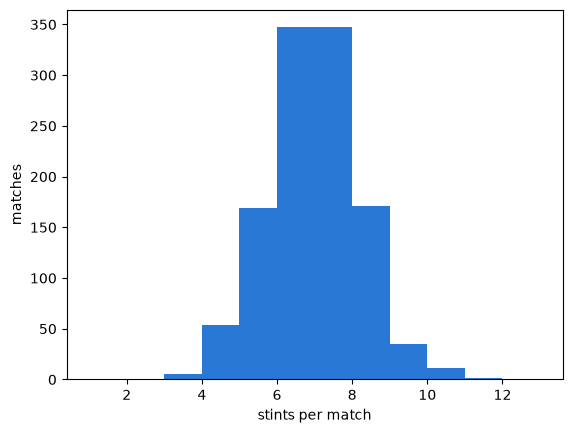

In [3]:
per_match = stints.groupby("match_id").agg(n_stints=("stint_idx", "count"),
                                           total_min=("duration", "sum"))
print(per_match.describe().round(2).to_string())
ax = per_match["n_stints"].hist(bins=range(1, 14), color="#2a78d6", grid=False)
ax.set_xlabel("stints per match"); ax.set_ylabel("matches");

count    7391.00
mean       13.99
std        18.79
min         1.00
25%         2.00
50%         6.00
75%        14.00
max        86.00
Name: duration, dtype: float64

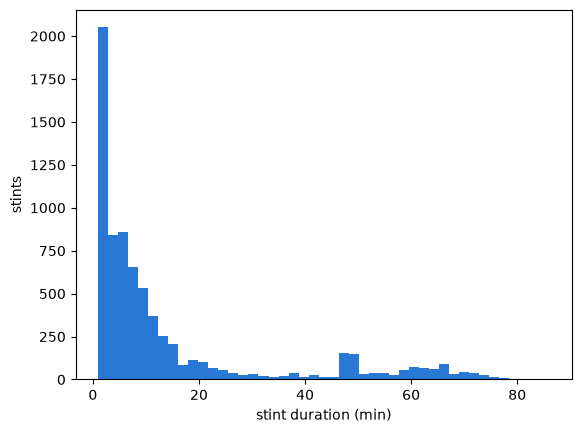

In [4]:
ax = stints["duration"].hist(bins=45, color="#2a78d6", grid=False)
ax.set_xlabel("stint duration (min)"); ax.set_ylabel("stints")
stints["duration"].describe().round(2)

In [5]:
# xG sanity: league totals per season, goals vs xG should track closely
sx = stints.groupby("season")[["h_goals", "a_goals", "h_xg", "a_xg"]].sum()
sx["goals"] = sx["h_goals"] + sx["a_goals"]
sx["xg"] = (sx["h_xg"] + sx["a_xg"]).round(1)
sx[["goals", "xg"]]

,goals,xg
season,,
2023,1246,1306.3
2024,1115,1236.5
2025,1045,1183.9


In [6]:
# Reconciliation gates (all must be OK)
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")
from plimpact.validate import run_all_checks
failures = run_all_checks(cfg)
assert all(f.empty for f in failures.values()), "reconciliation failure!"
print("\nAll gates passed.")

check scores                 OK


check kickoff_eleven         OK


check player_minutes         OK


check footballdata_scores    OK



All gates passed.


**Takeaways.** ~380 matches/season reconcile exactly: stint goals sum to final
scores, every match kicks off 11v11, per-player stint minutes match their
appearance intervals, and Understat's scores agree with football-data.co.uk.
The stint table is safe to model on.